Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### explainability of the fine-tuned BERT model

The best model in the comparison (notebook 07) is the **fine-tuned BERT**
(test accuracy 83.4%, macro-F1 0.841), so explanations are generated for it directly:

- **SHAP** — the *Partition explainer* with a `Text` masker: sub-phrases of the input are
  masked out and the change in class probability attributes importance to each token.
  Unlike the TreeExplainer used for XGBoost, this is model-agnostic and operates on the
  raw text the transformer actually sees.
- **LIME** — `LimeTextExplainer` perturbs the input by deleting words and fits a local
  linear surrogate to the model's probabilities.

Both methods therefore explain **the same model through the same interface**
(raw text in, class probabilities out), which makes their outputs directly comparable —
quantified at the end of this notebook by the overlap of their top-ranked tokens.

In [1]:
import pickle, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import shap
from pathlib import Path
from lime.lime_text import LimeTextExplainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')

SPLITS      = Path('..') / 'datasets' / 'processed' / 'splits'
MODELS_DIR  = Path('..') / 'models' / 'saved'
FT_DIR      = MODELS_DIR / 'bert_finetuned'
RESULTS_DIR = Path('..') / 'results'
CHARTS_DIR  = RESULTS_DIR / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
print('device:', DEVICE)

device: mps


---

### load the fine-tuned model

The `predict_proba` wrapper is the single interface both explainers use:
raw strings in, an `(N, 5)` probability matrix out.

In [2]:
with open(SPLITS / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
CLASS_NAMES = list(le.classes_)

with open(MODELS_DIR / 'best_model.json') as f:
    best_info = json.load(f)
print('best model:', best_info['model'],
      f"(acc {best_info['accuracy']:.4f}, macro-F1 {best_info['macro_f1']:.4f})")

tokenizer = AutoTokenizer.from_pretrained(FT_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(FT_DIR).to(DEVICE).eval()

@torch.no_grad()
def predict_proba(texts):
    texts = [str(t) for t in texts]
    out = []
    for i in range(0, len(texts), 64):
        enc = tokenizer(texts[i:i+64], max_length=128, padding=True,
                        truncation=True, return_tensors='pt')
        logits = model(input_ids=enc['input_ids'].to(DEVICE),
                       attention_mask=enc['attention_mask'].to(DEVICE)).logits
        out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(out)

test = pd.read_csv(SPLITS / 'test.csv')
test['text'] = test['text'].fillna('').astype(str)
print(f'classes: {CLASS_NAMES}  |  test samples: {len(test):,}')

best model: BERT (fine-tuned) (acc 0.8341, macro-F1 0.8410)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

classes: ['Anxiety/Stress', 'Bipolar', 'Depression', 'Normal', 'Suicidal']  |  test samples: 7,106


---

### explainers and plotting helpers

In [3]:
shap_explainer = shap.Explainer(predict_proba, shap.maskers.Text(tokenizer),
                                output_names=CLASS_NAMES)
lime_explainer = LimeTextExplainer(class_names=CLASS_NAMES, random_state=42)

LEGEND = [mpatches.Patch(color='#2ecc71', label='pushes toward prediction'),
          mpatches.Patch(color='#e74c3c', label='pushes away')]

def _bar(ax, words, scores, xlabel, title):
    colours = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores]
    ax.barh(words[::-1], scores[::-1], color=colours[::-1],
            edgecolor='black', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=10)
    ax.legend(handles=LEGEND, fontsize=7)
    ax.tick_params(labelsize=8)

def explain_shap(text, ax=None, top_n=12, max_evals=256):
    """Token-level SHAP explanation for the predicted class. Returns top tokens."""
    proba      = predict_proba([text])[0]
    pred_idx   = int(proba.argmax())
    sv         = shap_explainer([text], max_evals=max_evals, silent=True)
    vals       = sv.values[0][:, pred_idx]
    tokens     = np.array([t.strip() for t in sv.data[0]])
    keep       = np.array([len(t) > 0 for t in tokens])
    vals, tokens = vals[keep], tokens[keep]
    top        = np.argsort(np.abs(vals))[-top_n:][::-1]
    if ax is not None:
        _bar(ax, tokens[top].tolist(), vals[top].tolist(), 'SHAP value',
             f'SHAP — predicted: {CLASS_NAMES[pred_idx]} ({proba[pred_idx]:.0%})')
    return tokens[top].tolist(), CLASS_NAMES[pred_idx]

def explain_lime(text, ax=None, top_n=12, num_samples=300):
    """Word-level LIME explanation for the predicted class. Returns top words."""
    proba      = predict_proba([text])[0]
    pred_idx   = int(proba.argmax())
    exp        = lime_explainer.explain_instance(text, predict_proba,
                                                 num_features=top_n,
                                                 num_samples=num_samples,
                                                 top_labels=1)
    ww         = exp.as_list(label=exp.top_labels[0])
    words      = [w for w, _ in ww]
    scores     = [s for _, s in ww]
    if ax is not None:
        _bar(ax, words, scores, 'LIME weight',
             f'LIME — predicted: {CLASS_NAMES[pred_idx]} ({proba[pred_idx]:.0%})')
    return words, CLASS_NAMES[pred_idx]

print('explainers ready')

explainers ready


---

### individual explanations — one sample per class

A short, representative test post is chosen per class (100–400 characters, correctly
predicted where possible) so the charts stay readable.

In [4]:
def pick_example(cls_name):
    sub = test[(test['label'] == cls_name)
               & (test['text'].str.len().between(100, 400))]
    for _, row in sub.head(20).iterrows():
        p = predict_proba([row['text']])[0]
        if CLASS_NAMES[int(p.argmax())] == cls_name:
            return row['text']
    return sub.iloc[0]['text'] if len(sub) else \
           test[test['label'] == cls_name].iloc[0]['text']

examples = {c: pick_example(c) for c in CLASS_NAMES}
for c, t in examples.items():
    print(f'{c:<15} | {t[:90]}...')

Anxiety/Stress  | Tranquil Island Relaxation Relaxation for meditation, deep sleep, and anxiety/stress relie...
Bipolar         | Tapering/stoping seroquel any advice from tapering seroquel? 
tips and what to do? 
warnin...
Depression      | man i can barely remember when i wa doing that game style weight loss thing like depressio...
Normal          | She already knows the password to my laptop, email, bank account, and phone PIN. I didn't ...
Suicidal        | I do not really have enough energy to fight anymore sometimes i feel motivated and good bu...


SHAP Anxiety/Stress: 3.9s


SHAP Bipolar: 0.9s


SHAP Depression: 0.8s


SHAP Normal: 1.7s


SHAP Suicidal: 1.4s


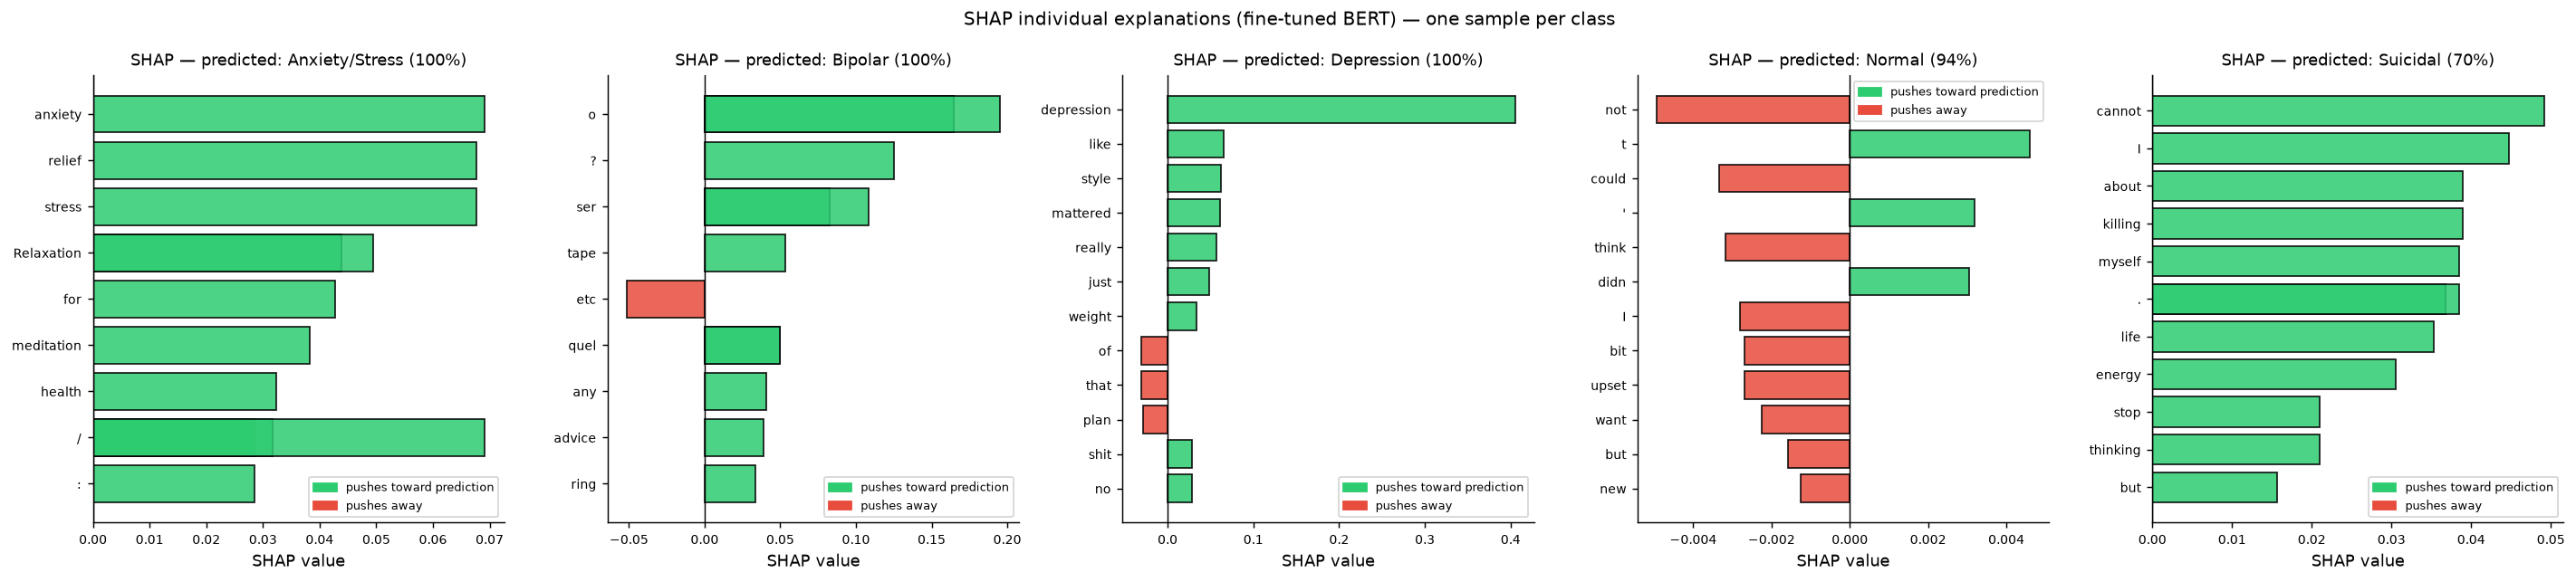

saved: charts/shap_individual_per_class.png


In [5]:
shap_top, lime_top = {}, {}

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(22, 5))
for ax, (cls, text) in zip(axes, examples.items()):
    t0 = time.time()
    shap_top[cls], _ = explain_shap(text, ax=ax)
    print(f'SHAP {cls}: {time.time()-t0:.1f}s')
plt.suptitle('SHAP individual explanations (fine-tuned BERT) — one sample per class',
             fontsize=11)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'shap_individual_per_class.png', bbox_inches='tight')
plt.show()
print('saved: charts/shap_individual_per_class.png')

LIME Anxiety/Stress: 1.2s


LIME Bipolar: 0.6s


LIME Depression: 0.7s


LIME Normal: 1.6s


LIME Suicidal: 1.2s


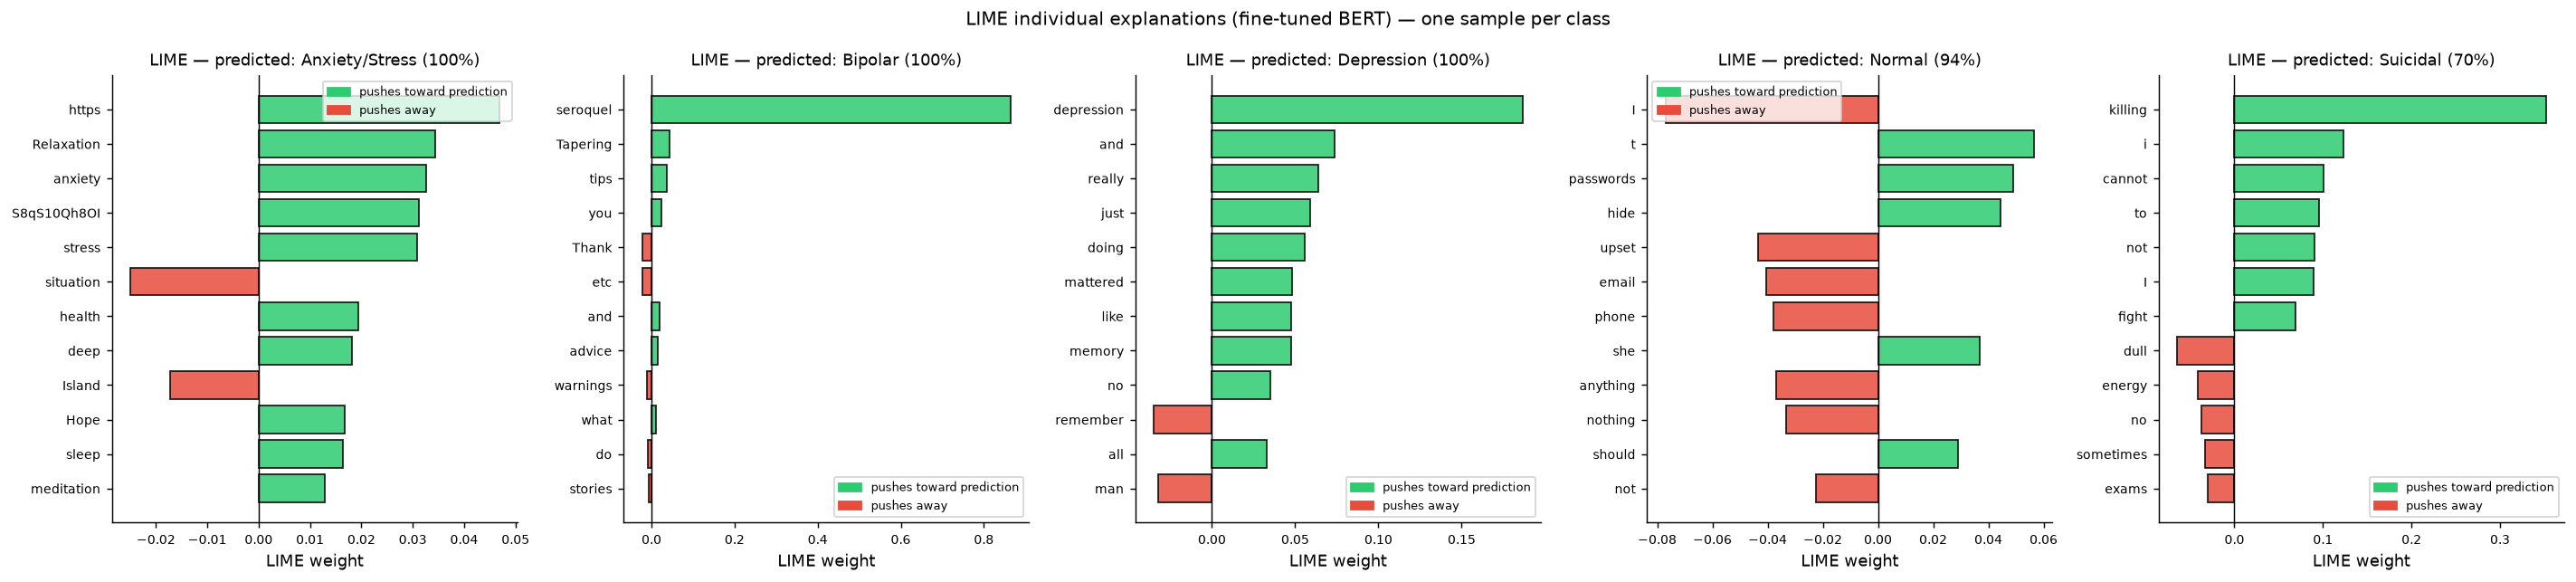

saved: charts/lime_individual_per_class.png


In [6]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(22, 5))
for ax, (cls, text) in zip(axes, examples.items()):
    t0 = time.time()
    lime_top[cls], _ = explain_lime(text, ax=ax)
    print(f'LIME {cls}: {time.time()-t0:.1f}s')
plt.suptitle('LIME individual explanations (fine-tuned BERT) — one sample per class',
             fontsize=11)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'lime_individual_per_class.png', bbox_inches='tight')
plt.show()
print('saved: charts/lime_individual_per_class.png')

---

### SHAP — global token importance

SHAP values are computed for a stratified sample of test posts (20 per class) and the
mean absolute SHAP value is aggregated per token per class. This is the transformer
analogue of the TF-IDF feature-importance chart produced for XGBoost.

In [7]:
np.random.seed(42)
SAMPLE_PER_CLASS = 20

pool = test[test['text'].str.len().between(80, 300)]
sample = (pool.groupby('label', group_keys=False)
              .apply(lambda g: g.sample(min(SAMPLE_PER_CLASS, len(g)), random_state=42)))
print(f'global sample: {len(sample)} posts')

from collections import defaultdict
tok_scores = {c: defaultdict(list) for c in CLASS_NAMES}

t0 = time.time()
for n, (_, row) in enumerate(sample.iterrows(), 1):
    sv = shap_explainer([row['text']], max_evals=128, silent=True)
    tokens = [t.strip().lower() for t in sv.data[0]]
    for ci, cls in enumerate(CLASS_NAMES):
        vals = sv.values[0][:, ci]
        for tk, v in zip(tokens, vals):
            if len(tk) > 2 and tk.isalpha():
                tok_scores[cls][tk].append(abs(v))
    if n % 20 == 0:
        print(f'  {n}/{len(sample)} posts explained ({(time.time()-t0)/60:.1f} min)')

print(f'done in {(time.time()-t0)/60:.1f} min')

global sample: 100 posts


  20/100 posts explained (0.2 min)


  40/100 posts explained (0.4 min)


  60/100 posts explained (0.5 min)


  80/100 posts explained (0.7 min)


  100/100 posts explained (0.8 min)
done in 0.8 min


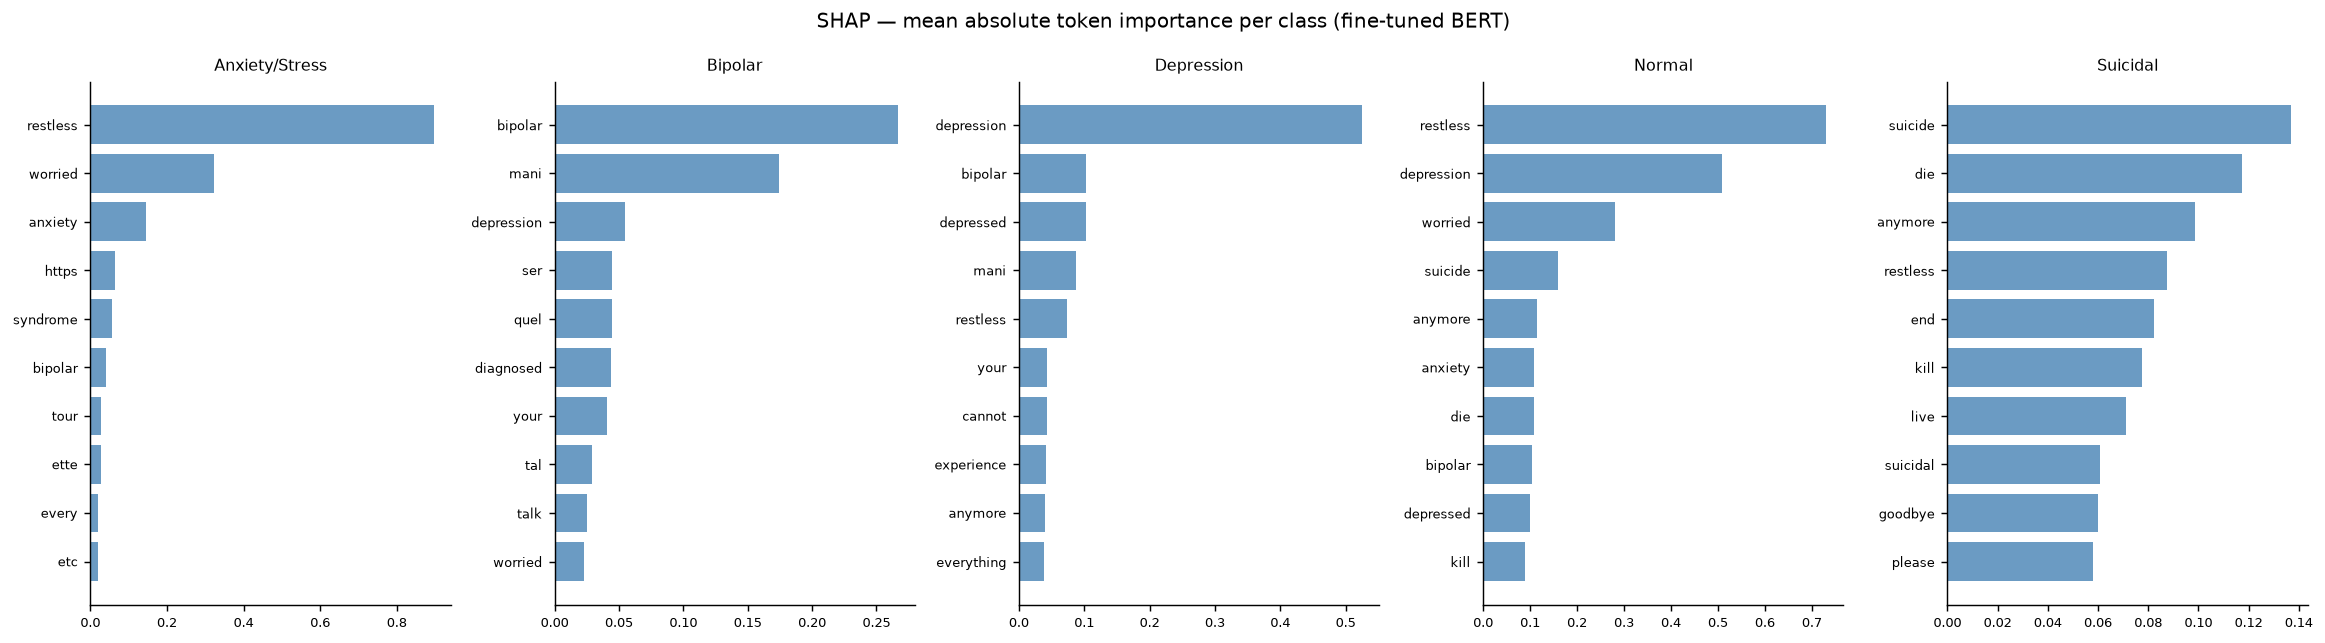

saved: charts/shap_global_importance.png


In [8]:
TOP_N = 10
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 5))

for ax, cls in zip(axes, CLASS_NAMES):
    # mean |SHAP| per token, requiring the token in at least 3 posts
    agg = {t: np.mean(v) for t, v in tok_scores[cls].items() if len(v) >= 3}
    top = sorted(agg.items(), key=lambda kv: kv[1], reverse=True)[:TOP_N]
    words = [w for w, _ in top][::-1]
    vals  = [v for _, v in top][::-1]
    ax.barh(words, vals, color='steelblue', alpha=0.8)
    ax.set_title(cls, fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle('SHAP — mean absolute token importance per class (fine-tuned BERT)',
             fontsize=11)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'shap_global_importance.png', bbox_inches='tight')
plt.show()
print('saved: charts/shap_global_importance.png')

---

### SHAP vs LIME — same prediction explained two ways

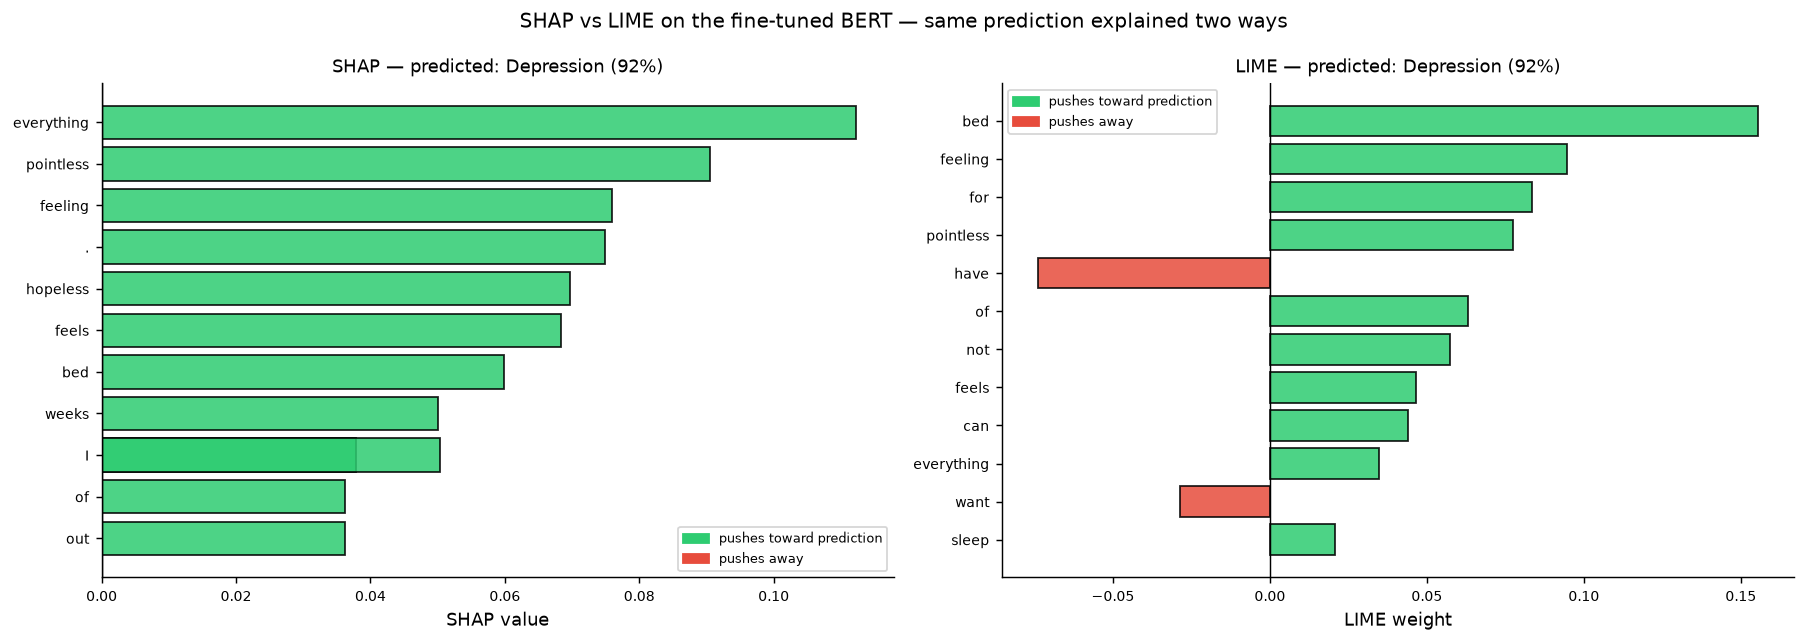

saved: charts/shap_vs_lime_comparison.png


In [9]:
example_text = ("I have been feeling hopeless for weeks, can not sleep, and "
                "everything feels pointless. I do not want to get out of bed.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
explain_shap(example_text, ax=ax1)
explain_lime(example_text, ax=ax2)
fig.suptitle('SHAP vs LIME on the fine-tuned BERT — same prediction explained two ways',
             fontsize=11)
plt.tight_layout()
fig.savefig(CHARTS_DIR / 'shap_vs_lime_comparison.png', bbox_inches='tight')
plt.show()
print('saved: charts/shap_vs_lime_comparison.png')

---

### quantitative agreement between SHAP and LIME

For each per-class example, the overlap between the two methods' top-12 tokens
(Jaccard index and raw intersection) measures how consistently they identify the
same evidence — a common sanity check when reporting post-hoc explanations.

In [10]:
def norm(ws):
    return {w.strip().lower().strip('.,!?;:\'"') for w in ws} - {''}

rows = []
for cls in CLASS_NAMES:
    s, l = norm(shap_top[cls]), norm(lime_top[cls])
    inter, union = s & l, s | l
    rows.append({'class': cls,
                 'shared_tokens': ', '.join(sorted(inter)[:8]),
                 'n_shared': len(inter),
                 'jaccard': round(len(inter) / len(union), 3) if union else 0.0})

agreement = pd.DataFrame(rows)
agreement.to_csv(RESULTS_DIR / 'shap_lime_agreement.csv', index=False)
print(agreement.to_string(index=False))
print()
print(f"mean Jaccard overlap: {agreement['jaccard'].mean():.3f}")
print('saved: results/shap_lime_agreement.csv')

         class                                   shared_tokens  n_shared  jaccard
Anxiety/Stress anxiety, health, meditation, relaxation, stress         5    0.333
       Bipolar                                     advice, etc         2    0.111
    Depression    depression, just, like, mattered, no, really         6    0.333
        Normal                                i, not, t, upset         4    0.211
      Suicidal                      cannot, energy, i, killing         4    0.235

mean Jaccard overlap: 0.245
saved: results/shap_lime_agreement.csv
